<a href="https://colab.research.google.com/github/Hyelimee/honmandeep/blob/main/%ED%98%BC%EB%A7%8C%EB%94%A5_chapter3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tensorflow_hub에서 모델 불러오기

In [ ]:
import tf_keras as keras
from tf_keras import layers
import tensorflow_hub as hub

In [ ]:
hub_efficientb0 = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1.0 / 255.0),
    hub.KerasLayer("https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-classification/1")
])

In [4]:
!gdown 1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
!unzip cat-dog-images.zip

import numpy as np
from PIL import Image

dog_png = np.array(Image.open('images/dog.png'))

Downloading...
From: https://drive.google.com/uc?id=1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
To: /content/cat-dog-images.zip
100% 182k/182k [00:00<00:00, 67.9MB/s]
Archive:  cat-dog-images.zip
   creating: images/
  inflating: images/dog.png          
  inflating: images/cat.png          


In [4]:
from keras.applications import efficientnet

predictions = hub_efficientb0.predict(dog_png[np.newaxis, :])
efficientnet.decode_predictions(predictions)

1/1 [==============================] - 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n02099712', 'Labrador_retriever', np.float32(0.3682943)),
  ('n02104029', 'kuvasz', np.float32(0.19339891)),
  ('n02099601', 'golden_retriever', np.float32(0.06145812)),
  ('n02111500', 'Great_Pyrenees', np.float32(0.05779673)),
  ('n02095889', 'Sealyham_terrier', np.float32(0.017902806))]]

## 허깅페이스로 강아지 사진 분류하기

In [1]:
from transformers import pipeline

In [2]:
pipe = pipeline(task='image-classification', device=0,
                model='google/efficientnet-b0')

#gpu 사용시 device = 0 지정, cpu = -1

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


In [5]:
pipe('images/dog.png')

[{'label': 'Labrador retriever', 'score': 0.3682946264743805},
 {'label': 'kuvasz', 'score': 0.19339881837368011},
 {'label': 'golden retriever', 'score': 0.061458297073841095},
 {'label': 'Great Pyrenees', 'score': 0.05779697746038437},
 {'label': 'Sealyham terrier, Sealyham', 'score': 0.01790272817015648}]

# Q. 사전 훈련된 모델은 1000개의 클래스에 대해 분류를 수행한다. 그런데 만약 분류하려는 이미지가 1000개의 클래스에 속해있지 않다면?

## 전이학습으로 피스타치오 품종 분류하기

In [17]:
#피스타치오 이미지 데이터셋 다운로드
!gdown 10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
!unzip -q Pistachio_Image_Dataset.zip

Downloading...
From: https://drive.google.com/uc?id=10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
To: /content/Pistachio_Image_Dataset.zip
100% 25.9M/25.9M [00:00<00:00, 36.7MB/s]
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 172.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ㅛ
error:  invalid response [ㅛ]
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 172.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 376.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 69.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [7]:
#피스타치오 이미지 크기 확인
pistachio_sample = np.array(Image.open('Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi (1).jpg'))
pistachio_sample.shape

(600, 600, 3)

In [19]:
#efficientNetB7 로 샘플예측 수행
import tf_keras as keras
from tf_keras import layers
from keras.applications import efficientnet

efficientb7 = keras.applications.EfficientNetB7()
predictions = efficientb7.predict(pistachio_sample[np.newaxis, :])
efficientnet.decode_predictions(predictions)

1/1 [==============================] - 10s 10s/step


[[('n01950731', 'sea_slug', np.float32(0.23482268)),
  ('n01924916', 'flatworm', np.float32(0.20674507)),
  ('n01943899', 'conch', np.float32(0.086223796)),
  ('n01945685', 'slug', np.float32(0.0850055)),
  ('n01955084', 'chiton', np.float32(0.028243236))]]

In [13]:
#EfficientNet을 base model로 가져오기
keras_efficientb0_base = keras.applications.EfficientNetB0(include_top=False)
feature_map = keras_efficientb0_base(pistachio_sample[np.newaxis, :])
feature_map.shape

#base_model만 불러오면 이미지 크기가 달라져도 입력처리에 문제가 되지 않음

16705208/16705208 [==============================] - 1s 0us/step


TensorShape([1, 18, 18, 1280])

In [6]:
#image_dataset_from_directory()를 이용해 폴더별로 나뉘어져 있는 이미지를 간편하게 로드할 수 있음
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    'Pistachio_Image_Dataset', image_size=(224, 224), batch_size=16,
    validation_split=0.2, subset='both', seed=42
)

'''이미지 자체는 600*600 인데 코랩 메모리 때문에 크기도 줄이고 batch_size도 낮게 설정함'''

Found 2148 files belonging to 2 classes.
Using 1719 files for training.
Using 429 files for validation.


'이미지 자체는 600*600 인데 코랩 메모리 때문에 크기도 줄이고 batch_size도 낮게 설정함'

In [17]:
#가중치가 변경되는 것을 막기 위해 설정
keras_efficientb0_base.trainable = False

In [22]:
#base model에 전역평균풀링과 밀집층 추가
inputs = keras.Input(shape=(224, 224, 3))
x = keras_efficientb0_base(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs= layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [23]:
rmsprop = keras.optimizers.RMSprop(learning_rate=5e-5)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy']) #이진분류
hist = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
108/108 [==============================] - 203s 2s/step - loss: 0.4835 - accuracy: 0.8069 - val_loss: 0.3508 - val_accuracy: 0.9068
Epoch 2/20
108/108 [==============================] - 162s 2s/step - loss: 0.3162 - accuracy: 0.9005 - val_loss: 0.2464 - val_accuracy: 0.9301
Epoch 3/20
108/108 [==============================] - 143s 1s/step - loss: 0.2337 - accuracy: 0.9343 - val_loss: 0.1933 - val_accuracy: 0.9417
Epoch 4/20
108/108 [==============================] - 121s 1s/step - loss: 0.1880 - accuracy: 0.9488 - val_loss: 0.1637 - val_accuracy: 0.9510
Epoch 5/20
108/108 [==============================] - 118s 1s/step - loss: 0.1521 - accuracy: 0.9628 - val_loss: 0.1385 - val_accuracy: 0.9604
Epoch 6/20
108/108 [==============================] - 127s 1s/step - loss: 0.1342 - accuracy: 0.9651 - val_loss: 0.1239 - val_accuracy: 0.9674
Epoch 7/20
108/108 [==============================] - 137s 1s/step - loss: 0.1252 - accuracy: 0.9622 - val_loss: 0.1157 - val_accuracy: 0.9697

In [42]:
#훈련한 모델 저장
import keras
model.save_weights('efficientb0_pistachio_weights.h5')

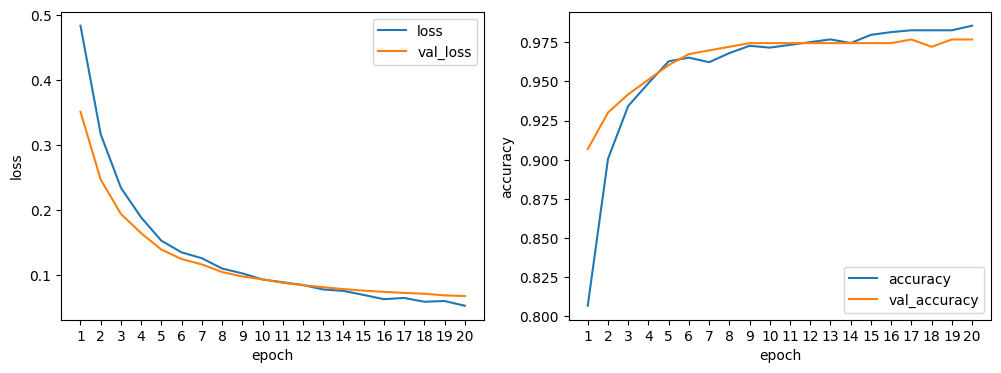

In [28]:
#손실, 정확도를 그래프로 그려서 시각화
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1, 21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1, 21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()

plt.show()

In [58]:
import keras
from keras import layers
from keras.applications import EfficientNetB0

keras_efficientb0_base = EfficientNetB0(include_top=False)
keras_efficientb0_base.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras_efficientb0_base(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.load_weights('efficientb0_pistachio_weights.h5')

In [66]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

# 예측할 샘플 준비
img = Image.open('Pistachio_Image_Dataset/Siirt_Pistachio/siirt (6).jpg')
img_resized = img.resize((224, 224))
img_array = np.array(img_resized).astype('float32')
img_pre = preprocess_input(img_array)
img_pist = np.expand_dims(img_pre, axis=0)  # (1, 224, 224, 3)

pred = model.predict(img_pist)
class_names = ['pistachio_kirmizi', 'pistachio_siirt']
predicted_class = class_names[int(pred[0][0] > 0.5)]
print(f"예측 클래스: {predicted_class}, 확률: {pred[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
예측 클래스: pistachio_siirt, 확률: 0.9529


## 캐글 모델로 동일한 작업 진행하기

In [7]:
import tf_keras as keras
from tf_keras import layers
import tensorflow_hub as hub

kaggle_efficientb0_base = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-feature-vector/1")

inputs = keras.Input(shape=(224, 224, 3))
x = layers.Rescaling(1.0 / 255.0)(inputs)
x = kaggle_efficientb0_base(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
108/108 [==============================] - 253s 2s/step - loss: 0.3862 - accuracy: 0.8668 - val_loss: 0.2495 - val_accuracy: 0.9347
Epoch 2/20
108/108 [==============================] - 111s 1s/step - loss: 0.2094 - accuracy: 0.9407 - val_loss: 0.1653 - val_accuracy: 0.9534
Epoch 3/20
108/108 [==============================] - 133s 1s/step - loss: 0.1493 - accuracy: 0.9599 - val_loss: 0.1309 - val_accuracy: 0.9604
Epoch 4/20
108/108 [==============================] - 136s 1s/step - loss: 0.1156 - accuracy: 0.9680 - val_loss: 0.1144 - val_accuracy: 0.9674
Epoch 5/20
108/108 [==============================] - 122s 1s/step - loss: 0.0952 - accuracy: 0.9715 - val_loss: 0.0960 - val_accuracy: 0.9744
Epoch 6/20
108/108 [==============================] - 106s 982ms/step - loss: 0.0812 - accuracy: 0.9732 - val_loss: 0.0866 - val_accuracy: 0.9744
Epoch 7/20
108/108 [==============================] - 123s 1s/step - loss: 0.0710 - accuracy: 0.9802 - val_loss: 0.0805 - val_accuracy: 0.9

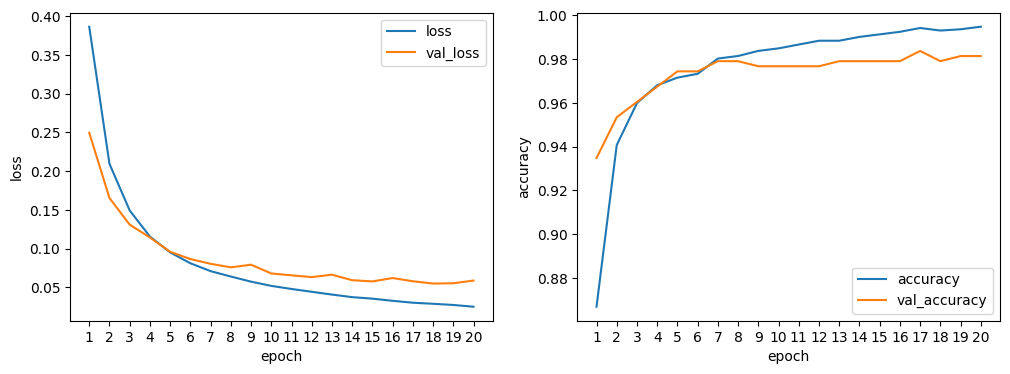

In [8]:
#그래프로 확인
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1, 21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1, 21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()

In [9]:
#훈련한 모델 저장
import keras
model.save_weights('kaggle_efficientb0_pistachio_weights.h5')

In [11]:
from PIL import Image
import numpy as np

#가중치 로딩
model.load_weights('kaggle_efficientb0_pistachio_weights.h5')

# 예측할 샘플 준비
img = Image.open('Pistachio_Image_Dataset/Siirt_Pistachio/siirt (6).jpg')
img = img.resize((224, 224))  # PIL 방식으로 리사이즈
img_array = np.array(img).astype('float32')  # (224, 224, 3), float32
img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

# 예측 (전처리는 모델 안에서 Rescaling으로 수행됨)
pred = model.predict(img_array)

# 결과 해석
class_names = ['pistachio_kirmizi', 'pistachio_siirt']
predicted_class = class_names[int(pred[0][0] > 0.5)]
print(f"예측 클래스: {predicted_class}, 확률: {pred[0][0]:.4f}")


1/1 [==============================] - 2s 2s/step
예측 클래스: pistachio_siirt, 확률: 0.9713


## 허깅페이스 모델로 동일한 작업 진행하기

In [1]:
pip install transformers torchvision

In [1]:
#피스타치오 이미지 데이터셋 다운로드
!gdown 10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
!unzip -q Pistachio_Image_Dataset.zip

Downloading...
From: https://drive.google.com/uc?id=10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
To: /content/Pistachio_Image_Dataset.zip
100% 25.9M/25.9M [00:00<00:00, 37.5MB/s]
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 172.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 376.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 69.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 371.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 188.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 447.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi 354.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [26]:
# Hugging Face EfficientNet-B0으로 피스타치오 분류 (PyTorch)

from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from torchvision import transforms
from torch.utils.data import Dataset
import torch
import os
from PIL import Image
from sklearn.model_selection import train_test_split

# 1. 클래스 이름 정의
class_names = ['Kirmizi_Pistachio', 'Siirt_Pistachio']
label2id = {v: k for k, v in enumerate(class_names)}
id2label = {k: v for v, k in label2id.items()}

# 2. 이미지 경로 및 라벨 로딩 함수
def get_image_paths_and_labels(root_dir):
    image_paths = []
    labels = []
    for cls_name in class_names:
        cls_path = os.path.join(root_dir, cls_name)
        for fname in os.listdir(cls_path):
            if fname.endswith(".jpg"):
                image_paths.append(os.path.join(cls_path, fname))
                labels.append(label2id[cls_name])
    return image_paths, labels

# 3. Hugging Face Processor 로딩
processor = AutoImageProcessor.from_pretrained("google/efficientnet-b0")

# 4. PyTorch Dataset 클래스 정의
class PistachioDataset(Dataset):
    def __init__(self, image_paths, labels, processor):
        self.image_paths = image_paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        encoding = self.processor(images=img, return_tensors="pt")
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["labels"] = torch.tensor(self.labels[idx])
        return encoding

# 5. 데이터 준비
image_paths, labels = get_image_paths_and_labels("Pistachio_Image_Dataset")
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

train_dataset = PistachioDataset(train_paths, train_labels, processor)
val_dataset = PistachioDataset(val_paths, val_labels, processor)

In [31]:
# 6. 모델 로딩 및 구성 수정
model = AutoModelForImageClassification.from_pretrained(
    "google/efficientnet-b0",
    num_labels=2,
    ignore_mismatched_sizes=True
)
model.config.id2label = id2label
model.config.label2id = label2id

# 7. 학습 설정
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    learning_rate=1e-4,
    logging_dir="./logs",
    logging_steps=10,
)

# 8. Trainer 구성 및 학습
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Some weights of EfficientNetForImageClassification were not initialized from the model checkpoint at google/efficientnet-b0 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1280]) in the checkpoint and torch.Size([2, 1280]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,0.572700
20,0.405300
30,0.255700
40,0.203800
50,0.144300
60,0.085200
70,0.073600
80,0.092400
90,0.085300
100,0.024100


TrainOutput(global_step=2160, training_loss=0.019170997517384995, metrics={'train_runtime': 7981.4282, 'train_samples_per_second': 4.305, 'train_steps_per_second': 0.271, 'total_flos': 1.244451520585728e+17, 'train_loss': 0.019170997517384995, 'epoch': 20.0})

In [35]:
trainer.evaluate()

{'eval_loss': 0.04803906008601189,
 'eval_runtime': 57.2227,
 'eval_samples_per_second': 7.515,
 'eval_steps_per_second': 0.472,
 'epoch': 20.0}

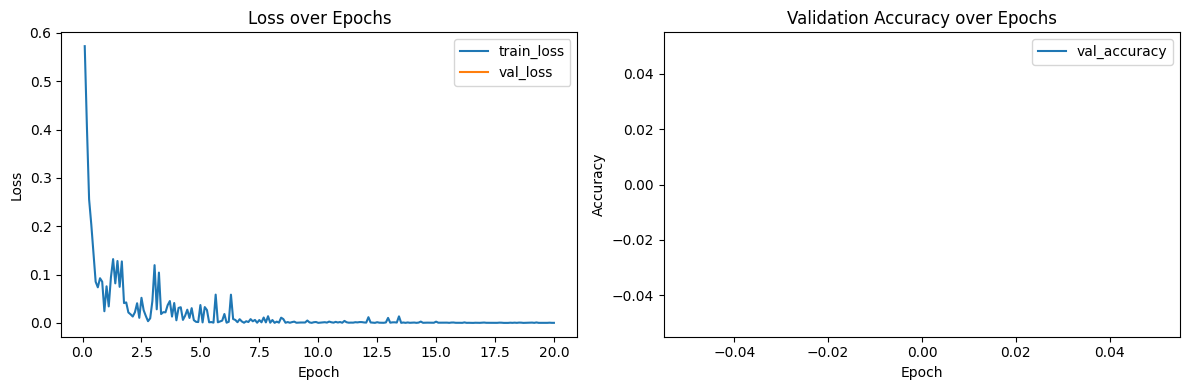

In [37]:
from collections import defaultdict
import matplotlib.pyplot as plt

# 1. log_history 불러오기
logs = trainer.state.log_history

# 2. loss, accuracy를 epoch별로 모으기
train_loss_per_epoch = defaultdict(list)
val_loss_per_epoch = {}
val_acc_per_epoch = {}

for entry in logs:
    if 'loss' in entry and 'epoch' in entry:  # 훈련 중 로깅
        train_loss_per_epoch[entry['epoch']].append(entry['loss'])
    elif 'eval_loss' in entry:  # 평가 시 로깅
        val_loss_per_epoch[entry['epoch']] = entry['eval_loss']
        val_acc_per_epoch[entry['epoch']] = entry.get('eval_accuracy', None)

# 3. epoch별 평균 loss 계산
epochs = sorted(train_loss_per_epoch.keys())
avg_train_loss = [sum(losses) / len(losses) for epoch, losses in sorted(train_loss_per_epoch.items())]
val_loss = [val_loss_per_epoch.get(epoch) for epoch in epochs]
val_acc = [val_acc_per_epoch.get(epoch) for epoch in epochs]

# 4. 그래프 그리기
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Loss 그래프
axs[0].plot(epochs, avg_train_loss, label="train_loss")
axs[0].plot(epochs, val_loss, label="val_loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss over Epochs")
axs[0].legend()

# Accuracy 그래프
axs[1].plot(epochs, val_acc, label="val_accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Validation Accuracy over Epochs")
axs[1].legend()

plt.tight_layout()
plt.show()

In [42]:
img = Image.open("Pistachio_Image_Dataset/Siirt_Pistachio/siirt (6).jpg").convert("RGB")
inputs = processor(images=img, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)

pred_idx = torch.argmax(probs, dim=1).item()
label = model.config.id2label[pred_idx]
score = probs[0][pred_idx].item()

print(f"예측: {label} (확률: {score:.4f})")

예측: Siirt_Pistachio (확률: 1.0000)
